In [1]:
from sacrebleu.metrics import BLEU
import re
import nltk
from nltk.tokenize import sent_tokenize
import os
import json
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../..')
from style_setup import set_thesis_style
set_thesis_style()

In [2]:
tokenizer = nltk.data.load('tokenizers/punkt/english.pickle') # tokenizer for splitting into sentences

# Helper functions

In [3]:
# Self-BLEU function 

def calculate_self_bleu(sentences, n_gram=4):
    """
    Calculate self-BLEU scores for a set of sentences.
    
    Args:
        sentences: List of sentences to compute self-BLEU for
        n_gram: Maximum n-gram order (default: 4)
    
    Returns:
        float: Average self-BLEU score
    """

    if len(sentences) < 2:
        return "too short"
    
    # Initialize BLEU scorer
    bleu = BLEU(max_ngram_order=n_gram, effective_order=True)


    scores = []
    for i in range(len(sentences)):
        hyp = [sentences[i]]
        # Wrap each other sentence in a list → each becomes a separate reference set
        refs = [[sentences[j]] for j in range(len(sentences)) if j != i]
        score = bleu.corpus_score(hyp, refs)
        scores.append(score.score)

        #print("Hypothesis:", hyp, "References:", refs, "Score:", score.score)

    average_self_bleu = sum(scores) / len(scores)

    
        
    return average_self_bleu


In [4]:
def remove_markdown(text):
    """
    Remove markdown formatting from a sentence.
    
    Args:
        sentence: Input sentence to remove markdown from
    """

    # Remove markdown formatting
    text = re.sub(r'#+', '', text)  # Remove all # symbols
    text = re.sub(r'\*\*', '', text)  # Remove **
    text = re.sub(r'\*', '', text)  # Remove *
    return text

def is_valid_sentence(sentence):
    """
    Check if a sentence is valid (not just a number or numbered list marker)
    Returns True if sentence is valid, False otherwise
    """
    # Strip whitespace
    sentence = sentence.strip()
    
    # Check if sentence is empty
    if not sentence:
        return False
    
    # Remove common markdown formatting characters
    cleaned = sentence.replace('#', '').replace('*', '').strip()
        
    # Check if sentence is just a number followed by a period (like "1.", "2.", "### 8.", "**2.", etc)
    if cleaned.replace('.', '').isdigit():
        return False
        
    # Check if sentence is too short (less than 3 characters)
    if len(cleaned) < 3:
        return False
        
    # Check if sentence starts with a number and period but has no other content
    if cleaned.split('.')[0].isdigit() and len(cleaned.split('.')) <= 2:
        return False
    
    return True


# Calculating self-bleu for 100 responses per dataset

### Data paths

In [5]:
model_paths = {
    "Small": [
        "../../Data/Finetuning/Augmented/Small/Llama/dolly_train_1_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Small/Llama/dolly_train_2_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Small/Llama/dolly_train_3_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Small/Llama/dolly_train_4_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Small/Other/dolly_train_2_Gemma.jsonl",
        "../../Data/Finetuning/Augmented/Small/Other/dolly_train_3_Qwen2.5-7B-Instruct.jsonl",
        "../../Data/Finetuning/Augmented/Small/Other/dolly_train_4_Falcon3-10B-Instruct.jsonl", # above here == small
    ],
    "Medium": [
        "../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_1_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_2_Llama.jsonl", 
        "../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_3_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_4_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Medium/Other/dolly_train_2_Mistral.jsonl",
        "../../Data/Finetuning/Augmented/Medium/Other/dolly_train_3_Qwen.jsonl",
        "../../Data/Finetuning/Augmented/Medium/Other/dolly_train_4_Command.jsonl",  # above here == medium
    ],
    "Large":[
        "../../Data/Finetuning/Augmented/Large/Llama/dolly_train_1_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Large/Llama/dolly_train_2_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Large/Llama/dolly_train_3_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Large/Llama/dolly_train_4_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Large/Other/dolly_train_2_Gemini.jsonl", 
        "../../Data/Finetuning/Augmented/Large/Other/dolly_train_3_GPT.jsonl",
        "../../Data/Finetuning/Augmented/Large/Other/dolly_train_4_Deepseek.jsonl",  # above here == large
    ]
}


## Model sentences

In [6]:
def self_bleu_individual_responses_model(data_paths, output_base_dir="../../Data/analysis/self_bleu", sample_number=500, save=False, n_gram=4, seed=42):
    """
    Calculate self-BLEU scores for individual responses from each dataset.
    
    Args:
        data_paths: Dictionary mapping model sizes to lists of file paths
        output_base_dir: Directory to save the results
        sample_number: Number of samples to use for calculation
        seed: Random seed for reproducibility
    """
    # Create output directories
    for size in ["Small", "Medium", "Large"]:
        os.makedirs(os.path.join(output_base_dir, size), exist_ok=True)

    np.random.seed(seed)  # Set seed for reproducibility

    # Process each dataset
    for size, file_paths in data_paths.items():
        print(f"Processing {size} models...")
        
        for file_path in tqdm(file_paths):
            # Extract model name from file path
            file_name = os.path.basename(file_path)
            model_name = file_name.split('.')[0]
            
            # Initialize data containers
            all_model_responses = []
            
            # Load the data
            with open(file_path, 'r') as f:
                for line in f:
                    data = json.loads(line)
                    response_key_model = [k for k in data.keys() if k.startswith('response_')][1]
                    response_model = data[response_key_model]
                    all_model_responses.append(response_model)

            clean_model_responses = []

            # Tokenize all responses
            for response_model in all_model_responses:
                response_model_sentences = sent_tokenize(response_model)
                valid_sentences = [s for s in response_model_sentences if is_valid_sentence(s)]
                clean_sentences = [remove_markdown(s) for s in valid_sentences]
                clean_sentences = [s for s in clean_sentences if len(s.split()) >= 4]
                clean_model_responses.append(clean_sentences) 
                
            indices = np.random.choice(len(clean_model_responses), size=sample_number, replace=False)
            response_samples = [clean_model_responses[i] for i in indices]

            self_bleu_4_scores = []
            lexical_diversity_scores = [] 

            too_short = 0
            
            for sample in response_samples:

                if len(sample) < 2:
                    too_short += 1
                    continue
                else:
                    self_bleu_4 = calculate_self_bleu(sample, n_gram)
                    lexical_diversity = 100-self_bleu_4
                    self_bleu_4_scores.append(self_bleu_4)
                    lexical_diversity_scores.append(lexical_diversity)

            print(f"Too short: {too_short/len(response_samples)}")

            average_self_bleu_4 = np.mean(self_bleu_4_scores)
            average_lexical_diversity = np.mean(lexical_diversity_scores)
            
            if save:
                # Save self-bleu scores
                model_output_file = os.path.join(output_base_dir, size, f"{model_name}_self_bleu.jsonl")
                with open(model_output_file, 'w') as f:
                    entry = {
                        "source": model_name,
                        "average_self_bleu_4": average_self_bleu_4,
                        "average_lexical_diversity": average_lexical_diversity,
                        "response_samples": response_samples,
                        "self_bleu_4_scores": self_bleu_4_scores,
                        "lexical_diversity_scores": lexical_diversity_scores
                    }
                    f.write(json.dumps(entry) + '\n')
                
                print(f"  Saved self-bleu scores to {model_output_file}")

    print("All self-bleu scores have been calculated.")




In [7]:
def self_bleu_all_responses_model(data_paths, output_base_dir="../../Data/analysis/self_bleu_combined", sample_number=100, save=False, n_gram=4, seed=42):
    """
    Calculate Self-BLEU scores for all model responses.
    
    Args:
        data_paths: Dictionary mapping size to list of file paths
        output_base_dir: Directory to save results
        sample_number: Number of responses to sample
        seed: Random seed for reproducibility
    """
    # Create output directories
    for size in ["Small", "Medium", "Large"]:
        os.makedirs(os.path.join(output_base_dir, size), exist_ok=True)

    np.random.seed(seed)  # Set seed for reproducibility

    # Process each dataset
    for size, file_paths in data_paths.items():
        print(f"Processing {size} models...")
        
        for file_path in tqdm(file_paths):
            # Extract model name from file path
            file_name = os.path.basename(file_path)
            model_name = file_name.split('.')[0]
            
            # Initialize data containers
            all_model_responses = []
            clean_model_responses = []
            
            # Load the data
            with open(file_path, 'r') as f:
                for line in f:
                    data = json.loads(line)
                    response_key_model = [k for k in data.keys() if k.startswith('response_')][1]
                    response_model = data[response_key_model]
                    all_model_responses.append(response_model)


            # Tokenize all responses
            for response_model in all_model_responses:
                response_model_sentences = sent_tokenize(response_model)
                valid_sentences = [s for s in response_model_sentences if is_valid_sentence(s)]
                clean_sentences = [remove_markdown(s) for s in valid_sentences]
                clean_sentences = [s for s in clean_sentences if len(s.split()) >= 4]
                
                # Filter out responses that are too short to match with individual conditions
                if len(clean_sentences) >= 2:
                    clean_model_responses.append(clean_sentences) 
                

            # Alternative approach if you need to sample whole responses
            indices = np.random.choice(len(clean_model_responses), size=sample_number, replace=False)
            response_samples = [clean_model_responses[i] for i in indices]


            joined_responses = " ".join([s for sublist in response_samples for s in sublist])
            response_sentences = sent_tokenize(joined_responses)
            response_sentences = [s for s in response_sentences if len(s.split()) >= 4]


            self_bleu_4 = calculate_self_bleu(response_sentences, n_gram)
            lexical_diversity = 100-self_bleu_4



            if save: 
                # Save self-bleu scores
                model_output_file = os.path.join(output_base_dir, size, f"{model_name}_self_bleu.jsonl")
                with open(model_output_file, 'w') as f:
                    entry = {
                        "source": model_name,
                        #"self_bleu_1": self_bleu_1,
                        #"self_bleu_2": self_bleu_2,
                        #"self_bleu_3": self_bleu_3,
                        "self_bleu_4": self_bleu_4,
                        #"self_bleu_average": self_bleu_average,
                        "lexical_diversity": lexical_diversity,
                        "response_sentences": response_sentences
                    }
                    f.write(json.dumps(entry) + '\n')
                
                print(f"  Saved self-bleu scores to {model_output_file}")

    print("All self-bleu scores have been calculated.")




## Human sentences

In [8]:
# Config

human_paths = [
    "../../Data/Finetuning/Dolly/dolly_train_1.jsonl",
    "../../Data/Finetuning/Dolly/dolly_train_2.jsonl",
    "../../Data/Finetuning/Dolly/dolly_train_3.jsonl",
    "../../Data/Finetuning/Dolly/dolly_train_4.jsonl"
]
def self_bleu_individual_responses_human(data_paths_human, output_base_dir, sample_number=500, save=False, n_gram=4, seed=42):
    """
    Process human datasets to calculate self-BLEU scores and lexical diversity.
    
    Args:
        data_paths_human: List of paths to human dataset files
        output_base_dir: Base directory to save output files
        sample_number: Number of samples to use (default: 500)
        seed: Random seed for reproducibility (default: 42)
    """
    # Create output directories
    os.makedirs(os.path.join(output_base_dir, "Human"), exist_ok=True)

    np.random.seed(seed)  # Set seed for reproducibility

    # Process each human dataset
    print("Processing human datasets...")

    for file_path in tqdm(data_paths_human):
        # Extract dataset name from file path
        file_name = os.path.basename(file_path)
        dataset_name = file_name.split('.')[0]
        
        # Initialize data containers
        all_human_responses = []
        clean_human_responses = []
        
        # Load the data
        with open(file_path, 'r') as f:
            for line in f:
                data = json.loads(line)
                # Get the human response (typically the first response key)
                response_key_human = [k for k in data.keys() if k.startswith('response_human')][0]
                response_human = data[response_key_human]
                all_human_responses.append(response_human)
        
        # Tokenize all responses
        for response_human in all_human_responses:
            response_human_sentences = sent_tokenize(response_human)
            valid_sentences = [s for s in response_human_sentences if is_valid_sentence(s)]
            clean_sentences = [remove_markdown(s) for s in valid_sentences]
            clean_sentences = [s for s in clean_sentences if len(s.split()) >= 4]
            clean_human_responses.append(clean_sentences) # this is where either a list of lists or a list of strings is stored (append or extend)
                

        # Alternative approach if you need to sample whole responses
        indices = np.random.choice(len(clean_human_responses), size=sample_number, replace=False)
        response_samples = [clean_human_responses[i] for i in indices]

        self_bleu_4_scores = []
        lexical_diversity_scores = []
        
        too_short = 0
            
        for sample in response_samples:

            if len(sample) < 2:
                too_short += 1
                continue
            else:
                self_bleu_4 = calculate_self_bleu(sample, n_gram)
                lexical_diversity = 100-self_bleu_4
                self_bleu_4_scores.append(self_bleu_4)
                lexical_diversity_scores.append(lexical_diversity)

        print(f"Too short: {too_short/len(response_samples)}")

        average_self_bleu_4 = np.mean(self_bleu_4_scores)
        average_lexical_diversity = np.mean(lexical_diversity_scores)

        if save: 
            # Save self-bleu scores
            model_output_file = os.path.join(output_base_dir, "Human", f"{dataset_name}_self_bleu.jsonl")
            with open(model_output_file, 'w') as f:
                entry = {
                    "source": dataset_name,
                    "average_self_bleu_4": average_self_bleu_4,
                    "average_lexical_diversity": average_lexical_diversity,
                    "response_samples": response_samples,
                    "self_bleu_4_scores": self_bleu_4_scores,
                    "self_bleu_4_scores": self_bleu_4_scores,
                    "lexical_diversity_scores": lexical_diversity_scores
                }
                f.write(json.dumps(entry) + '\n')
            
            print(f"  Saved self-bleu scores to {model_output_file}")

    print("All self-bleu scores have been calculated.")


In [9]:
def self_bleu_all_responses_human(data_paths_human, output_base_dir, sample_number=100, save=False, n_gram=4, seed=42):
    """
    Calculate Self-BLEU scores for all human responses combined.
    
    Args:
        data_paths_human: List of paths to human response data files
        output_base_dir: Base directory to save output files
        sample_number: Number of responses to sample (default: 100)
    """
    # Create output directories
    os.makedirs(os.path.join(output_base_dir, "Human"), exist_ok=True)

    np.random.seed(seed)  # Set seed for reproducibility

    # Process each human dataset
    print("Processing human datasets...")

    for file_path in tqdm(data_paths_human):
        # Extract dataset name from file path
        file_name = os.path.basename(file_path)
        dataset_name = file_name.split('.')[0]
        
        # Initialize data containers
        all_human_responses = []
        clean_human_responses = []
        
        # Load the data
        with open(file_path, 'r') as f:
            for line in f:
                data = json.loads(line)
                # Get the human response (typically the first response key)
                response_key_human = [k for k in data.keys() if k.startswith('response_human')][0]
                response_human = data[response_key_human]
                all_human_responses.append(response_human)
        
        # Tokenize all responses
        for response_human in all_human_responses:
            response_human_sentences = sent_tokenize(response_human)
            valid_sentences = [s for s in response_human_sentences if is_valid_sentence(s)]
            clean_sentences = [remove_markdown(s) for s in valid_sentences]
            clean_sentences = [s for s in clean_sentences if len(s.split()) >= 4]
            # Filter out responses that are too short to match with individual conditions
            if len(clean_sentences) >= 2:
                clean_human_responses.append(clean_sentences)                

        # Alternative approach if you need to sample whole responses
        indices = np.random.choice(len(clean_human_responses), size=sample_number, replace=False)
        response_samples = [clean_human_responses[i] for i in indices]


        joined_responses = " ".join([s for sublist in response_samples for s in sublist])
        response_sentences = sent_tokenize(joined_responses)
        response_sentences = [s for s in response_sentences if len(s.split()) >= 4]

        
        self_bleu_4 = calculate_self_bleu(response_sentences, n_gram)
        lexical_diversity = 100-self_bleu_4

        if save: 
            # Save self-bleu scores
            human_output_file = os.path.join(output_base_dir, "Human", f"{dataset_name}_self_bleu.jsonl")
            with open(human_output_file, 'w') as f:
                entry = {
                    "source": dataset_name,
                    "self_bleu_4": self_bleu_4,
                    "lexical_diversity": lexical_diversity,
                    "response_sentences": response_sentences
                }
                f.write(json.dumps(entry) + '\n')
            
            print(f"  Saved self-bleu scores to {human_output_file}")

    print("All self-bleu scores have been calculated.")


## Calculate scores

In [14]:
# Self-BLEU model scores for individual responses
save = True
n_gram = 3
sample_number = 500
output_base_dir = f"../../Data/analysis/self_bleu_{n_gram}"
self_bleu_individual_responses_model(model_paths, output_base_dir, sample_number, save, n_gram)

Processing Small models...


 14%|█▍        | 1/7 [00:02<00:15,  2.57s/it]

Too short: 0.176
  Saved self-bleu scores to ../../Data/analysis/self_bleu_3/Small/dolly_train_1_Llama_self_bleu.jsonl


 29%|██▊       | 2/7 [00:05<00:12,  2.54s/it]

Too short: 0.17
  Saved self-bleu scores to ../../Data/analysis/self_bleu_3/Small/dolly_train_2_Llama_self_bleu.jsonl


...

Too short: 0.368
  Saved self-bleu scores to ../../Data/analysis/self_bleu_3/Large/dolly_train_2_Gemini_self_bleu.jsonl


 86%|████████▌ | 6/7 [00:16<00:02,  2.87s/it]

Too short: 0.152
  Saved self-bleu scores to ../../Data/analysis/self_bleu_3/Large/dolly_train_3_GPT_self_bleu.jsonl


100%|██████████| 7/7 [00:19<00:00,  2.83s/it]

Too short: 0.106
  Saved self-bleu scores to ../../Data/analysis/self_bleu_3/Large/dolly_train_4_Deepseek_self_bleu.jsonl
All self-bleu scores have been calculated.


In [15]:
# Self-BLEU model scores for all responses

save = True
sample_number = 100
output_base_dir = f"../../Data/analysis/self_bleu_combined_{n_gram}"
self_bleu_all_responses_model(model_paths, output_base_dir, sample_number, save, n_gram)

Processing Small models...


 14%|█▍        | 1/7 [00:33<03:21, 33.55s/it]

  Saved self-bleu scores to ../../Data/analysis/self_bleu_combined_3/Small/dolly_train_1_Llama_self_bleu.jsonl


 29%|██▊       | 2/7 [01:12<03:02, 36.54s/it]

  Saved self-bleu scores to ../../Data/analysis/self_bleu_combined_3/Small/dolly_train_2_Llama_self_bleu.jsonl


...

  Saved self-bleu scores to ../../Data/analysis/self_bleu_combined_3/Large/dolly_train_2_Gemini_self_bleu.jsonl


 86%|████████▌ | 6/7 [05:22<00:55, 55.05s/it]

  Saved self-bleu scores to ../../Data/analysis/self_bleu_combined_3/Large/dolly_train_3_GPT_self_bleu.jsonl


100%|██████████| 7/7 [06:20<00:00, 54.32s/it]

  Saved self-bleu scores to ../../Data/analysis/self_bleu_combined_3/Large/dolly_train_4_Deepseek_self_bleu.jsonl
All self-bleu scores have been calculated.


In [16]:
#  Self-BLEU human scores for individual responses

save = True
sample_number = 500
output_base_dir = f"../../Data/analysis/self_bleu_{n_gram}"

self_bleu_individual_responses_human(human_paths, output_base_dir, sample_number, save, n_gram)

Processing human datasets...


 25%|██▌       | 1/4 [00:00<00:02,  1.34it/s]

Too short: 0.534
  Saved self-bleu scores to ../../Data/analysis/self_bleu_3/Human/dolly_train_1_self_bleu.jsonl


 50%|█████     | 2/4 [00:01<00:01,  1.43it/s]

Too short: 0.514
  Saved self-bleu scores to ../../Data/analysis/self_bleu_3/Human/dolly_train_2_self_bleu.jsonl


 75%|███████▌  | 3/4 [00:02<00:00,  1.44it/s]

Too short: 0.474
  Saved self-bleu scores to ../../Data/analysis/self_bleu_3/Human/dolly_train_3_self_bleu.jsonl


100%|██████████| 4/4 [00:02<00:00,  1.41it/s]

Too short: 0.474
  Saved self-bleu scores to ../../Data/analysis/self_bleu_3/Human/dolly_train_4_self_bleu.jsonl
All self-bleu scores have been calculated.


In [17]:
# Self-BLEU human scores for all responses

save = True
sample_number = 100
output_base_dir = f"../../Data/analysis/self_bleu_combined_{n_gram}"
self_bleu_all_responses_human(human_paths, output_base_dir, sample_number, save, n_gram)

Processing human datasets...


 25%|██▌       | 1/4 [00:17<00:52, 17.43s/it]

  Saved self-bleu scores to ../../Data/analysis/self_bleu_combined_3/Human/dolly_train_1_self_bleu.jsonl


 50%|█████     | 2/4 [00:34<00:33, 16.98s/it]

  Saved self-bleu scores to ../../Data/analysis/self_bleu_combined_3/Human/dolly_train_2_self_bleu.jsonl


 75%|███████▌  | 3/4 [00:44<00:14, 14.16s/it]

  Saved self-bleu scores to ../../Data/analysis/self_bleu_combined_3/Human/dolly_train_3_self_bleu.jsonl


100%|██████████| 4/4 [00:56<00:00, 14.17s/it]

  Saved self-bleu scores to ../../Data/analysis/self_bleu_combined_3/Human/dolly_train_4_self_bleu.jsonl
All self-bleu scores have been calculated.


# Plotting self-bleu scores

## Creating summary datasets

In [20]:
# Initialize lists to store data
n_gram = 4
self_bleu_data = []

# Process each directory
for size in ["Human", "Small", "Medium", "Large"]:
    dir_path = f"../../Data/analysis/self_bleu_{n_gram}/{size}"
    
    # Process each file in the directory
    for file in os.listdir(dir_path):
        if file.endswith(".jsonl"):
            file_path = os.path.join(dir_path, file)
            
            # Read the JSONL file
            with open(file_path, 'r') as f:
                for line in f:
                    entry = json.loads(line)
                    
                    # Extract the data we need
                    self_bleu_data.append({
                        "dataset": entry["source"].split("_")[0] + "_" + entry["source"].split("_")[1] + "_" + entry["source"].split("_")[2],
                        "model": entry["source"].split("_")[-1] if len(entry["source"].split("_")) > 2 else "Human",
                        "size": size,
                        f"self_bleu_{n_gram}": entry["average_self_bleu_4"],
                        "lexical_diversity": entry["average_lexical_diversity"],
                        "lexical_diversity_scores": entry["lexical_diversity_scores"]
                    })

# Create DataFrame
df = pd.DataFrame(self_bleu_data)

# Sort by size and source
df = df.sort_values(["size", "model", "dataset"])
# Reset the index of the DataFrame
df = df.reset_index(drop=True)
# Assuming 'df' is your DataFrame
df.loc[0:3, 'model'] = 'Human'

df.loc[18, 'model'] = 'Falcon'
df.to_pickle(f"../../Data/analysis/self_bleu_{n_gram}/self_bleu_data.pkl")
df.head(25)

,dataset,model,size,self_bleu_4,lexical_diversity,lexical_diversity_scores
0,dolly_train_1,Human,Human,7.264739,92.735261,"[92.42387853708763, 93.47514519991132, 98.5736..."
1,dolly_train_2,Human,Human,7.232833,92.767167,"[97.45404698649499, 90.7441933042195, 95.60194..."
2,dolly_train_3,Human,Human,7.754770,92.245230,"[91.39061509559372, 41.772067556870375, 98.574..."
3,dolly_train_4,Human,Human,7.486377,92.513623,"[90.59448271270782, 97.85540757653855, 91.5796..."
4,dolly_train_4,Deepseek,Large,12.250364,87.749636,"[90.87426631640261, 94.72288924676903, 80.4301..."
5,dolly_train_3,GPT,Large,11.629938,88.370062,"[90.9314216129955, 90.76242050388312, 56.51551..."
6,dolly_train_2,Gemini,Large,12.367377,87.632623,"[66.74105704313314, 85.51083484854834, 98.2723..."
7,dolly_train_1,Llama,Large,14.622396,85.377604,"[83.16113669989906, 96.24135933591624, 88.1528..."
8,dolly_train_2,Llama,Large,14.268462,85.731538,"[98.2014636591495, 88.3834826540536, 56.614728..."
9,dolly_train_3,Llama,Large,15.159793,84.840207,"[70.51568052963377, 76.2148426697768, 98.99632..."


In [23]:
# SELF BLEU COMBINED
# Initialize lists to store data
n_gram = 4
self_bleu_data_combined = []

# Process each directory
for size in ["Human", "Small", "Medium", "Large"]:
    dir_path = f"../../Data/analysis/self_bleu_combined_{n_gram}/{size}"
    
    # Process each file in the directory
    for file in os.listdir(dir_path):
        if file.endswith(".jsonl"):
            file_path = os.path.join(dir_path, file)
            
            # Read the JSONL file
            with open(file_path, 'r') as f:
                for line in f:
                    entry = json.loads(line)
                    
                    # Extract the data we need
                    self_bleu_data_combined.append({
                        "dataset": entry["source"].split("_")[0] + "_" + entry["source"].split("_")[1] + "_" + entry["source"].split("_")[2],
                        "model": entry["source"].split("_")[-1] if len(entry["source"].split("_")) > 2 else "Human",
                        "size": size,
                        f"self_bleu_{n_gram}": entry["self_bleu_4"],
                        "lexical_diversity": entry["lexical_diversity"],
                    })

# Create DataFrame
df_combined = pd.DataFrame(self_bleu_data_combined)

# Sort by size and source
df_combined = df_combined.sort_values(["size", "model", "dataset"])
# Reset the index of the DataFrame
df_combined = df_combined.reset_index(drop=True)
df_combined.loc[0:3, 'model'] = 'Human'
df_combined.loc[18, 'model'] = 'Falcon'
df_combined.to_pickle(f"../../Data/analysis/self_bleu_combined_{n_gram}/self_bleu_combined_data.pkl")
df_combined.head(25)

,dataset,model,size,self_bleu_4,lexical_diversity
0,dolly_train_1,Human,Human,18.156057,81.843943
1,dolly_train_2,Human,Human,15.011641,84.988359
2,dolly_train_3,Human,Human,15.263775,84.736225
3,dolly_train_4,Human,Human,16.987418,83.012582
4,dolly_train_4,Deepseek,Large,21.385177,78.614823
5,dolly_train_3,GPT,Large,22.243191,77.756809
6,dolly_train_2,Gemini,Large,24.298829,75.701171
7,dolly_train_1,Llama,Large,30.715078,69.284922
8,dolly_train_2,Llama,Large,29.125735,70.874265
9,dolly_train_3,Llama,Large,25.699093,74.300907


## Load data

In [2]:
n_gram = 3
df = pd.read_pickle(f"../../Data/analysis/self_bleu_{n_gram}/self_bleu_data.pkl")
df_aggregated = pd.read_pickle(f"../../Data/analysis/self_bleu_combined_{n_gram}/self_bleu_combined_data.pkl")

# Group by 'size' and calculate the mean for each metric
avg_by_size = df.groupby('size')[[f'self_bleu_{n_gram}', 'lexical_diversity']].mean().reset_index()

avg_by_size_aggregated = df_aggregated.groupby('size')[[f'self_bleu_{n_gram}', 'lexical_diversity']].mean().reset_index()


avg_by_size.to_pickle(f"../../Data/analysis/self_bleu_{n_gram}/avg_by_size.pkl")
avg_by_size_aggregated.to_pickle(f"../../Data/analysis/self_bleu_combined_{n_gram}/avg_by_size_aggregated.pkl")


In [29]:
# Concatenate avg_by_size and avg_by_size_combined

# First, add a column to identify the source of each dataframe
avg_by_size['Preprocessing'] = 'individual responses'
avg_by_size_aggregated['Preprocessing'] = 'aggregated responses'

# Concatenate the dataframes
avg_by_size_all = pd.concat([avg_by_size, avg_by_size_aggregated], ignore_index=True)

avg_by_size_all.to_pickle(f"../../Data/analysis/self_bleu_{n_gram}/avg_by_size_all.pkl")

avg_by_size_all.head(10)


,size,self_bleu_3,lexical_diversity,Preprocessing
0,Human,10.841940,89.158060,individual responses
1,Large,19.043206,80.956794,individual responses
2,Medium,21.107692,78.892308,individual responses
3,Small,20.497975,79.502025,individual responses
4,Human,25.811892,74.188108,aggregated responses
5,Large,37.413133,62.586867,aggregated responses
6,Medium,39.742667,60.257333,aggregated responses
7,Small,39.191644,60.808356,aggregated responses


## Plot

### Summary plot

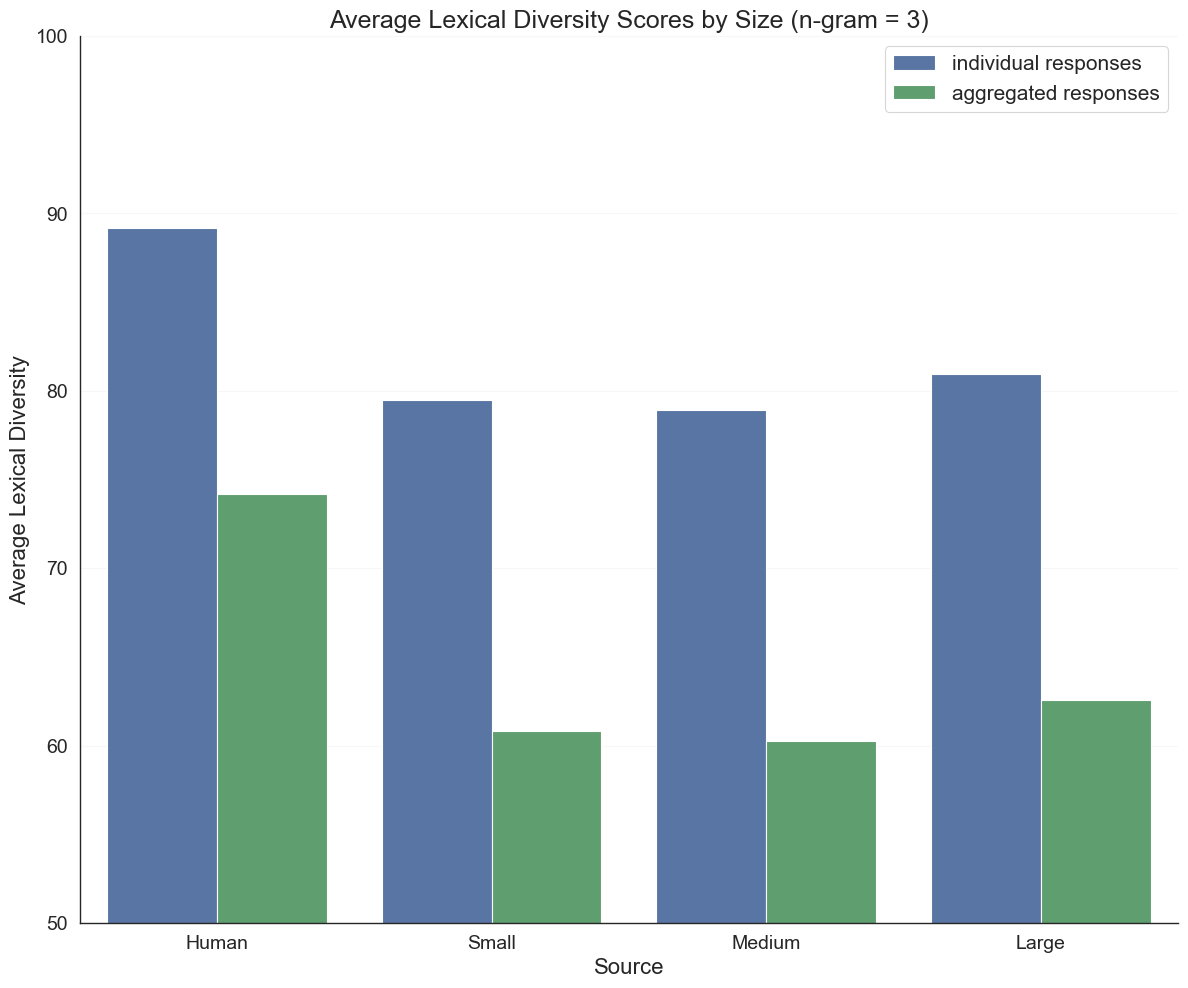

In [25]:
n_gram = 3
avg_by_size_all = pd.read_pickle(f"../../Data/analysis/self_bleu_{n_gram}/avg_by_size_all.pkl")

# Create the bar plot with reordered categories
plt.figure(figsize=(12, 10))
plt.grid(True, linestyle='-', alpha=0.3)
sns.barplot(
    data=avg_by_size_all, 
    x="size", 
    y="lexical_diversity", 
    hue="Preprocessing", 
    order=["Human", "Small", "Medium", "Large"]
)

plt.title(f"Average Lexical Diversity Scores by Size (n-gram = {n_gram})", fontsize=18)
plt.ylabel("Average Lexical Diversity", fontsize=16)
plt.xlabel("Source", fontsize=16)

# Set y-axis grid lines every 10 steps
plt.yticks(np.arange(0, 101, 10), fontsize=14)
plt.grid(axis='y', which='major', linestyle='-', alpha=0.3)

# Increase x-axis tick font size
plt.xticks(fontsize=14)
plt.ylim(50, 100)

# Increase legend font size
plt.legend(fontsize=15)

plt.tight_layout()
plt.show()

In [26]:
avg_by_size_all.head(25)

,size,self_bleu_3,lexical_diversity,Preprocessing
0,Human,10.841940,89.158060,individual responses
1,Large,19.043206,80.956794,individual responses
2,Medium,21.107692,78.892308,individual responses
3,Small,20.497975,79.502025,individual responses
4,Human,25.811892,74.188108,aggregated responses
5,Large,37.413133,62.586867,aggregated responses
6,Medium,39.742667,60.257333,aggregated responses
7,Small,39.191644,60.808356,aggregated responses


### Individual models

In [16]:
n_gram = 3

self_bleu_data = pd.read_pickle(f"../../Data/analysis/self_bleu_{n_gram}/self_bleu_data.pkl")
self_bleu_data_combined = pd.read_pickle(f"../../Data/analysis/self_bleu_combined_{n_gram}/self_bleu_combined_data.pkl")

# Define the order for size categories
size_order = ["Human", "Small", "Medium", "Large"]

# Convert 'size' column to categorical type with the specified order
self_bleu_data['size'] = pd.Categorical(self_bleu_data['size'], categories=size_order, ordered=True)
self_bleu_data_combined['size'] = pd.Categorical(self_bleu_data_combined['size'], categories=size_order, ordered=True)

# Sort the dataframes by 'size'
self_bleu_data = self_bleu_data.sort_values('size')
self_bleu_data_combined = self_bleu_data_combined.sort_values('size')

# Reset the index of self_bleu_data
self_bleu_data.reset_index(drop=True, inplace=True)
self_bleu_data_combined.reset_index(drop=True, inplace=True)

self_bleu_data.at[10, 'model'] = 'Qwen'
self_bleu_data_combined.at[10, 'model'] = 'Qwen'

# Swap the row at index 11 with that at index 17
self_bleu_data.iloc[[11, 17]] = self_bleu_data.iloc[[17, 11]].values

self_bleu_data_combined.head(25)


,dataset,model,size,self_bleu_3,lexical_diversity
0,dolly_train_1,Human,Human,27.817671,72.182329
1,dolly_train_2,Human,Human,24.425078,75.574922
2,dolly_train_3,Human,Human,24.936844,75.063156
3,dolly_train_4,Human,Human,26.067974,73.932026
4,dolly_train_3,Llama,Small,46.347424,53.652576
5,dolly_train_2,Llama,Small,44.595332,55.404668
6,dolly_train_1,Llama,Small,43.223165,56.776835
7,dolly_train_2,Gemma,Small,30.728718,69.271282
8,dolly_train_4,Falcon,Small,33.136307,66.863693
9,dolly_train_4,Llama,Small,43.809057,56.190943


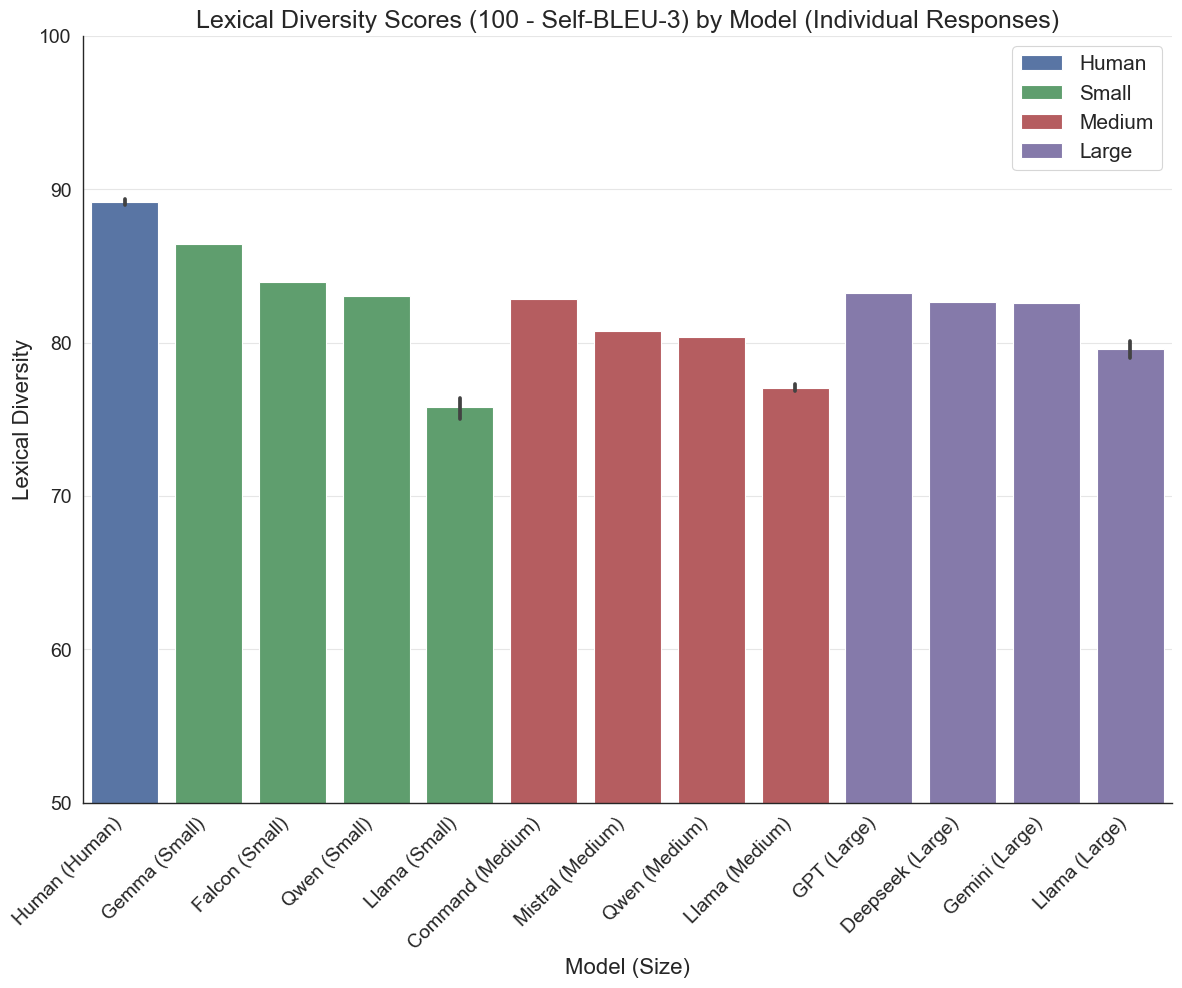

In [21]:
# Create a plot to visualize self_bleu scores by model, split by size
plt.figure(figsize=(12, 10))

# Add a new column to combine model name and size
self_bleu_data['model_with_size'] = self_bleu_data['model'] + ' (' + self_bleu_data['size'].astype(str) + ')'

# Use the thesis color palette instead of hardcoded colors
# Get the current palette set by thesis style
current_palette = sns.color_palette()

# Map sizes to colors from the thesis palette
size_palette = {
    "Human": current_palette[0],    # Red from thesis palette
    "Small": current_palette[1],    # Sand/yellow from thesis palette  
    "Medium": current_palette[2],   # Green from thesis palette
    "Large": current_palette[3]     # Blue from thesis palette
}

# Sort the data within each size by lexical diversity score in descending order
self_bleu_data_sorted = self_bleu_data.sort_values(by=['size', 'lexical_diversity'], ascending=[True, False])

# Create the bar plot with thesis style colors
sns.barplot(
    data=self_bleu_data_sorted,
    x='model_with_size',
    y='lexical_diversity',
    hue='size',
    palette=size_palette,
    dodge=False
)

plt.title(f"Lexical Diversity Scores (100 - Self-BLEU-{n_gram}) by Model (Individual Responses)", fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(np.arange(0, 101, 10), fontsize=14)
plt.ylabel("Lexical Diversity", fontsize=16)
plt.xlabel("Model (Size)", fontsize=16)
plt.ylim(50, 100)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

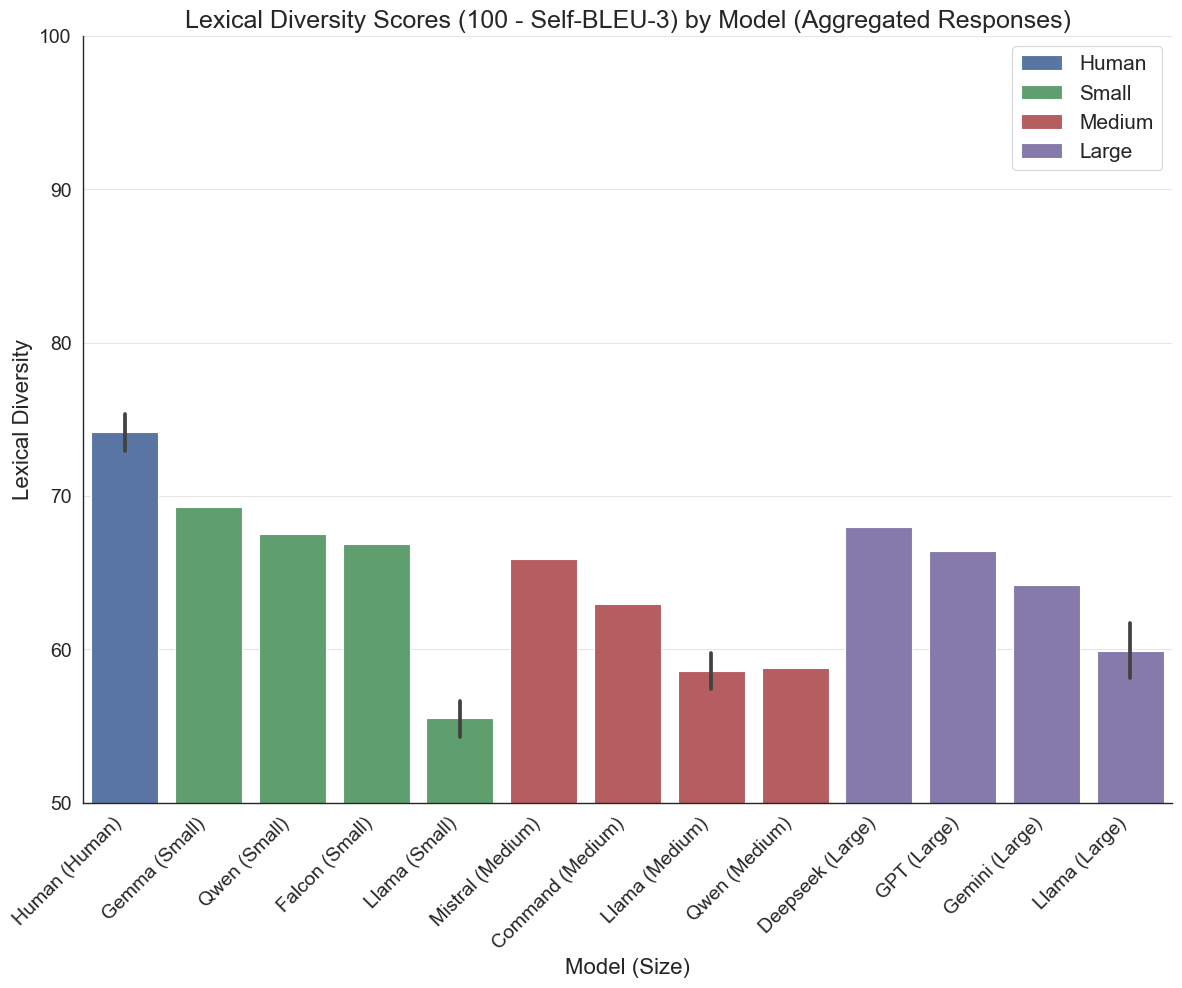

In [23]:
n_gram = 3

# Create a plot to visualize self_bleu scores by model, split by size
plt.figure(figsize=(12, 10))

# Add a new column to combine model name and size
self_bleu_data_combined['model_with_size'] = self_bleu_data_combined['model'] + ' (' + self_bleu_data_combined['size'].astype(str) + ')'

# Use the thesis color palette instead of hardcoded colors
# Get the current palette set by thesis style
current_palette = sns.color_palette()

# Map sizes to colors from the thesis palette
size_palette = {
    "Human": current_palette[0],    # Red from thesis palette
    "Small": current_palette[1],    # Sand/yellow from thesis palette  
    "Medium": current_palette[2],   # Green from thesis palette
    "Large": current_palette[3]     # Blue from thesis palette
}

# Sort the data within each size by lexical diversity score in descending order
self_bleu_data_combined_sorted = self_bleu_data_combined.sort_values(by=['size', 'lexical_diversity'], ascending=[True, False])

# Create the bar plot with thesis style colors
sns.barplot(
    data=self_bleu_data_combined_sorted,
    x='model_with_size',
    y='lexical_diversity',
    hue='size',
    palette=size_palette,
    dodge=False
)

plt.title(f"Lexical Diversity Scores (100 - Self-BLEU-{n_gram}) by Model (Aggregated Responses)", fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(np.arange(0, 101, 10), fontsize=14)
plt.ylabel("Lexical Diversity", fontsize=16)
plt.xlabel("Model (Size)", fontsize=16)
plt.ylim(50, 100)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()


# Scores for table

In [3]:
summary_df_aggregated = pd.read_pickle("/Users/maxschaffelder/Desktop/Thesis/data/data_analysis/self_bleu_combined_3/self_bleu_combined_data.pkl")

In [4]:
display(summary_df_aggregated)

,dataset,model,size,self_bleu_3,lexical_diversity
0,dolly_train_1,Human,Human,27.817671,72.182329
1,dolly_train_2,Human,Human,24.425078,75.574922
2,dolly_train_3,Human,Human,24.936844,75.063156
3,dolly_train_4,Human,Human,26.067974,73.932026
4,dolly_train_4,Deepseek,Large,32.041209,67.958791
5,dolly_train_3,GPT,Large,33.615265,66.384735
6,dolly_train_2,Gemini,Large,35.804854,64.195146
7,dolly_train_1,Llama,Large,42.701589,57.298411
8,dolly_train_2,Llama,Large,40.818393,59.181607
9,dolly_train_3,Llama,Large,37.432945,62.567055


In [9]:
summary_df_individual = pd.read_pickle("/Users/maxschaffelder/Desktop/Thesis/data/data_analysis/self_bleu_3/self_bleu_data.pkl")
display(summary_df_individual)

,dataset,model,size,self_bleu_3,lexical_diversity,lexical_diversity_scores
0,dolly_train_1,Human,Human,10.551254,89.448746,"[89.49556106682073, 89.522840501334, 97.762797..."
1,dolly_train_2,Human,Human,10.723868,89.276132,"[96.32065423709727, 85.03650615680384, 93.1155..."
2,dolly_train_3,Human,Human,11.087045,88.912955,"[85.28448750016196, 35.20746054532809, 98.0676..."
3,dolly_train_4,Human,Human,11.005592,88.994408,"[85.13702202269421, 96.89134751477035, 88.0445..."
4,dolly_train_4,Deepseek,Large,17.365324,82.634676,"[85.79200894062797, 91.11224681985156, 71.7671..."
5,dolly_train_3,GPT,Large,16.732626,83.267374,"[84.94130794315647, 84.18623297667364, 48.0223..."
6,dolly_train_2,Gemini,Large,17.436954,82.563046,"[59.51763216216418, 76.8259142161298, 97.50568..."
7,dolly_train_1,Llama,Large,20.078246,79.921754,"[77.42174080806848, 94.2379804061835, 80.81744..."
8,dolly_train_2,Llama,Large,19.690675,80.309325,"[97.1026695545192, 82.21722370860432, 48.92425..."
9,dolly_train_3,Llama,Large,20.789179,79.210821,"[61.73658306279442, 67.96297262078063, 98.4425..."


In [10]:
exploded_df = summary_df_individual.explode('lexical_diversity_scores')

# Ensure the scores column is treated as a numeric type for calculations.
exploded_df['lexical_diversity_scores'] = pd.to_numeric(exploded_df['lexical_diversity_scores'])

grouped_scores = exploded_df.groupby(['model', 'size'])

lexical_diversity_stats = grouped_scores['lexical_diversity_scores'].agg(
    mean='mean',
    median='median',
    min='min',
    max='max',
    std='std'
).reset_index()

# To make the output cleaner, we can sort it by size category.
size_order = ['Small', 'Medium', 'Large', 'Human']
lexical_diversity_stats['size'] = pd.Categorical(lexical_diversity_stats['size'], categories=size_order, ordered=True)
lexical_diversity_stats = lexical_diversity_stats.sort_values('size').reset_index(drop=True)

# Display the final aggregated statistics
display(lexical_diversity_stats)


,model,size,mean,median,min,max,std
0,Falcon,Small,83.964625,86.001894,37.510836,99.464068,10.909668
1,Gemma,Small,86.447662,87.590164,51.673232,100.000000,7.977721
2,Llama,Small,75.774552,76.390318,5.119195,100.000000,14.535395
3,Qwen2,Small,83.021232,84.636415,12.355380,99.693894,11.047215
4,Command,Medium,82.867762,83.371585,41.985345,100.000000,9.574788
5,Llama,Medium,77.064378,78.009117,5.636819,100.000000,13.321166
6,Mistral,Medium,80.767552,82.210220,30.880883,98.906108,10.806042
7,Qwen,Medium,80.363553,82.463555,9.643003,98.812925,13.046752
8,Deepseek,Large,82.634676,84.155094,28.735504,99.318877,10.882195
9,GPT,Large,83.267374,84.465371,29.407731,100.000000,10.412185


In [12]:
lexical_diversity_stats.to_csv("lexical_diversity_individual_stats.csv", index=False)

# Understanding cases where lexical diversity = 100

In [11]:
# --- Calculate Overall Proportion ---

# Total number of individual lexical diversity scores calculated
total_scores = len(exploded_df)

# Number of scores that are exactly 100
scores_at_100 = (exploded_df['lexical_diversity_scores'] == 100).sum()

# Calculate the overall proportion
overall_proportion = (scores_at_100 / total_scores) * 100 if total_scores > 0 else 0

print(f"Overall, {scores_at_100} out of {total_scores} lexical diversity scores are exactly 100.")
print(f"This is {overall_proportion:.2f}% of all scores.\n")


# --- Calculate Proportion by Group ---

print("Proportion of scores at 100, broken down by model and size:")

# Group by model and size as before
grouped = exploded_df.groupby(['model', 'size'])

# For each group, calculate the mean of a boolean series (True for 100, False otherwise).
# This is a fast way to get the proportion.
proportion_by_group = grouped['lexical_diversity_scores'].apply(lambda x: (x == 100).mean() * 100).reset_index(name='percentage_at_100')

# To make the output cleaner, we can sort it by size category.
size_order = ['Human', 'Large', 'Medium', 'Small']
proportion_by_group['size'] = pd.Categorical(proportion_by_group['size'], categories=size_order, ordered=True)
proportion_by_group = proportion_by_group.sort_values('size').reset_index(drop=True)


# Display the resulting table
display(proportion_by_group)

Overall, 32 out of 9329 lexical diversity scores are exactly 100.
This is 0.34% of all scores.

Proportion of scores at 100, broken down by model and size:


,model,size,percentage_at_100
0,Human,Human,0.099800
1,Deepseek,Large,0.000000
2,GPT,Large,0.235849
3,Gemini,Large,0.000000
4,Llama,Large,1.196474
5,Command,Medium,0.298507
6,Llama,Medium,0.326797
7,Mistral,Medium,0.000000
8,Qwen,Medium,0.000000
9,Falcon,Small,0.000000


In [28]:
import json
import os

# List of files to inspect
files_to_check = [
    "/Users/maxschaffelder/Desktop/Thesis/data/data_analysis/self_bleu_3/Small/dolly_train_2_Gemma_self_bleu.jsonl",
    "/Users/maxschaffelder/Desktop/Thesis/data/data_analysis/self_bleu_3/Large/dolly_train_1_Llama_self_bleu.jsonl"
]

# Iterate through each file
for file_path in files_to_check:
    print(f"--- Checking file: {os.path.basename(file_path)} ---")
    total_found = 0
    
    if not os.path.exists(file_path):
        print(f"Error: The file '{file_path}' was not found.")
        print("-" * 40 + "\n")
        continue

    # Open and read the JSONL file line by line
    with open(file_path, 'r') as f:
        for i, line in enumerate(f):
            try:
                data = json.loads(line)
                
                lex_scores = data.get('lexical_diversity_scores', [])
                all_responses = data.get('response_samples', [])
                
                # Recreate the filtered list of responses that actually got scored
                scored_responses = [resp for resp in all_responses if len(resp) >= 2]
                
                # --- Data Validation ---
                if len(lex_scores) != len(scored_responses):
                    print(f"Warning on line {i+1}: Mismatch still exists after filtering. Scores: {len(lex_scores)}, Filtered Responses: {len(scored_responses)}. Skipping.")
                    continue
                # --- End Validation ---

                # Find all indices where the lexical diversity score is 100
                indices_of_100 = [idx for idx, score in enumerate(lex_scores) if score == 100.0]

                if indices_of_100:
                    total_found += len(indices_of_100)
                    print(f"\n[Found {len(indices_of_100)} instance(s) on line {i+1}]")
                    
                    # Print the specific responses that scored 100
                    print("\nResponse(s) with lexical diversity of 100:")
                    for index in indices_of_100:
                        # Use the index on the 'scored_responses' list
                        print(f"  - {repr(scored_responses[index])}")
                    
            except (json.JSONDecodeError, KeyError) as e:
                print(f"Warning: Could not process line {i+1}. Error: {e}")

    if total_found == 0:
        print("No cases with a lexical diversity score of 100 were found in this file.")
        
    print(f"\n--- Finished checking {os.path.basename(file_path)} ---")
    print("-" * 40 + "\n")

--- Checking file: dolly_train_2_Gemma_self_bleu.jsonl ---

[Found 4 instance(s) on line 1]

Response(s) with lexical diversity of 100:
  - ['The paragraph states that Roger Franklin Bonk was a native of Minnesota.', 'Let me know if you have any other questions about him!']
  - ['According to the text, Ling Ling practices 40 hours a day.', 'Let me know if you have any other questions!']
  - ["According to the paragraph, Berwick's population was 10,355 as of the 2020 census.", 'Let me know if you have any other questions about Berwick!']
  - ['Please provide me with the list of cities!', "😊  \n\nI'm ready to tell you which ones are in Latvia."]

--- Finished checking dolly_train_2_Gemma_self_bleu.jsonl ---
----------------------------------------

--- Checking file: dolly_train_1_Llama_self_bleu.jsonl ---

[Found 3 instance(s) on line 1]

Response(s) with lexical diversity of 100:
  - ['Unfortunately, the text doesn\'t mention who wrote the song "House of Love" by Vika and Linda.', 'Can

# Correlation of lexical diversity with semantic diversity

In [62]:
sem_div_scores = pd.read_csv("/Users/maxschaffelder/Desktop/Thesis/data/data_analysis/semantic_diversity/div_sem_std_err_all_with_averages.csv")
lex_div_scores = pd.read_csv("/Users/maxschaffelder/Desktop/Thesis/code/data_analysis/lexical_diversity/lexical_diversity_individual_stats.csv")
display(sem_div_scores)

,dataset,size,model,semantic diversity,standard_error
0,dolly_train_1,Human,Human,0.971391,0.000012
1,dolly_train_2,Human,Human,0.971526,0.000012
2,dolly_train_3,Human,Human,0.971009,0.000012
3,dolly_train_4,Human,Human,0.971923,0.000012
4,dolly_train_1,Small,Llama,0.957039,0.000012
5,dolly_train_2,Small,Llama,0.957276,0.000012
6,dolly_train_3,Small,Llama,0.956871,0.000012
7,dolly_train_4,Small,Llama,0.955551,0.000012
8,dolly_train_2,Small,Gemma,0.935083,0.000013
9,dolly_train_3,Small,Qwen,0.951034,0.000013


--- Data prepared for regression ---


,model,size,mean_lexical_diversity,mean_semantic_diversity
0,Falcon,Small,83.964625,0.961050
1,Gemma,Small,86.447662,0.935083
2,Llama,Small,75.774552,0.956684
3,Qwen,Small,83.021232,0.951034
4,Command,Medium,82.867762,0.961000
5,Llama,Medium,77.064378,0.954133
6,Mistral,Medium,80.767552,0.951268
7,Qwen,Medium,80.363553,0.949204
8,Deepseek,Large,82.634676,0.944782
9,GPT,Large,83.267374,0.953917




--- Linear Regression Model Summary ---
                               OLS Regression Results                              
Dep. Variable:     mean_semantic_diversity   R-squared:                       0.008
Model:                                 OLS   Adj. R-squared:                 -0.082
Method:                      Least Squares   F-statistic:                   0.09120
Date:                     Wed, 16 Jul 2025   Prob (F-statistic):              0.768
Time:                             12:22:40   Log-Likelihood:                 42.129
No. Observations:                       13   AIC:                            -80.26
Df Residuals:                           11   BIC:                            -79.13
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

/Users/maxschaffelder/.pyenv/versions/thesis_env/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=13 observations were given.
  return hypotest_fun_in(*args, **kwds)


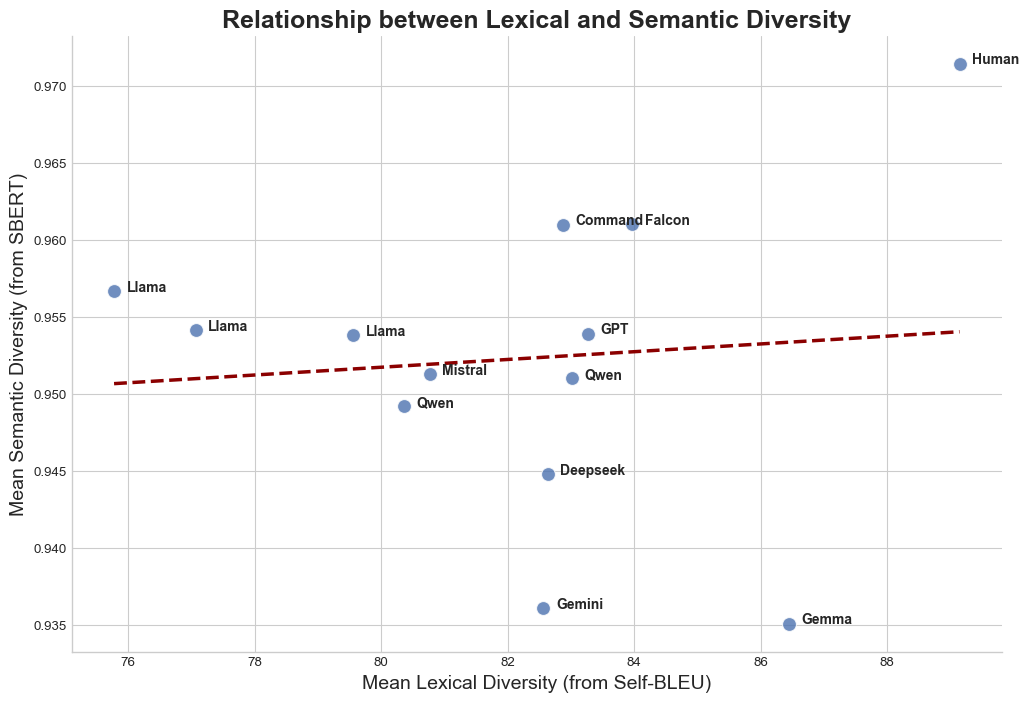

In [36]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Aggregate the semantic diversity scores ---
# Group by model and size, then calculate the mean semantic diversity for each group.
sem_div_agg = sem_div_scores.groupby(['model', 'size'])['semantic diversity'].mean().reset_index()
sem_div_agg = sem_div_agg.rename(columns={'semantic diversity': 'mean_semantic_diversity'})

# --- 2. Prepare the lexical diversity scores ---
# We just need the model, size, and mean columns.
lex_div_agg = lex_div_scores[['model', 'size', 'mean']].copy()
lex_div_agg = lex_div_agg.rename(columns={'mean': 'mean_lexical_diversity'})

# --- 3. Merge the two aggregated DataFrames ---
# To ensure the merge works, we'll standardize the 'Qwen2' name from the lexical data.
lex_div_agg['model'] = lex_div_agg['model'].replace('Qwen2', 'Qwen')

# Perform an inner merge to align both metrics by model and size.
merged_df = pd.merge(lex_div_agg, sem_div_agg, on=['model', 'size'])

print("--- Data prepared for regression ---")
display(merged_df)

# --- 4. Fit the Linear Regression Model ---
# Define the dependent variable (Y) and the independent variable (X)
Y = merged_df['mean_semantic_diversity']
X = merged_df['mean_lexical_diversity']

# Add a constant (i.e., the intercept) to the independent variable
X = sm.add_constant(X)

# Create and fit the Ordinary Least Squares (OLS) model
model = sm.OLS(Y, X)
results = model.fit()

# --- 5. Display the Statistical Summary ---
print("\n\n--- Linear Regression Model Summary ---")
print(results.summary())
print("\n" * 2)

# --- 6. Visualize the Relationship ---
print("--- Scatter Plot with Regression Line ---")
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))

# Create a regression plot
sns.regplot(
    x='mean_lexical_diversity',
    y='mean_semantic_diversity',
    data=merged_df,
    ax=ax,
    ci=None, # You can set this to 95 to view the confidence interval
    scatter_kws={'s': 100, 'alpha': 0.8, 'edgecolor': 'w'},
    line_kws={'color': 'darkred', 'linestyle': '--', 'linewidth': 2.5}
)

# Annotate each point on the scatter plot with its corresponding model name
for i, row in merged_df.iterrows():
    # Add a small offset to the text position for better readability
    ax.text(row['mean_lexical_diversity'] + 0.2, row['mean_semantic_diversity'], row['model'], fontsize=10, weight='bold')

ax.set_title('Relationship between Lexical and Semantic Diversity', fontsize=18, weight='bold')
ax.set_xlabel('Mean Lexical Diversity (from Self-BLEU)', fontsize=14)
ax.set_ylabel('Mean Semantic Diversity (from SBERT)', fontsize=14)

plt.show()

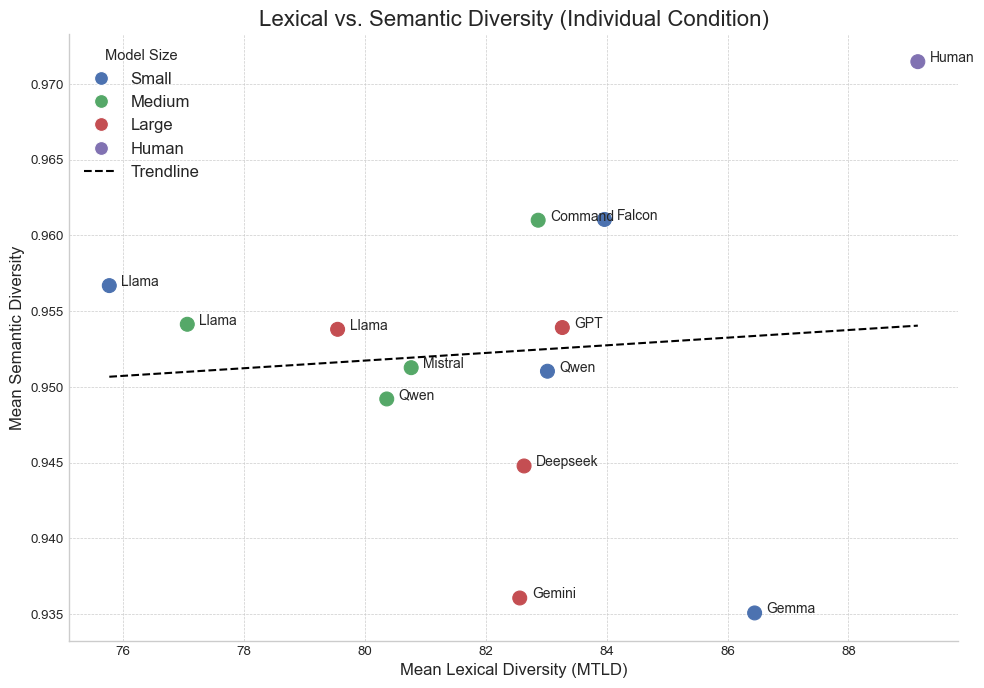

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# If 'set_thesis_style' is not defined, you might need to import it.
# For example: from code.style_setup import set_thesis_style

# Recreate the DataFrame
data = {
    'model': ['Falcon', 'Gemma', 'Llama', 'Qwen', 'Command', 'Llama', 'Mistral', 'Qwen', 'Deepseek', 'GPT', 'Gemini', 'Llama', 'Human'],
    'size': ['Small', 'Small', 'Small', 'Small', 'Medium', 'Medium', 'Medium', 'Medium', 'Large', 'Large', 'Large', 'Large', 'Human'],
    'mean_lexical_diversity': [83.964625, 86.447662, 75.774552, 83.021232, 82.867762, 77.064378, 80.767552, 80.363553, 82.634676, 83.267374, 82.563046, 79.550648, 89.147000],
    'mean_semantic_diversity': [0.961050, 0.935083, 0.956684, 0.951034, 0.961000, 0.954133, 0.951268, 0.949204, 0.944782, 0.953917, 0.936069, 0.953800, 0.971462]
}
merged_df = pd.DataFrame(data)

# This assumes set_thesis_style() is available in your environment.
# set_thesis_style()

# Create the plot
plt.figure(figsize=(10, 7))

# Define colors for different sizes
size_colors = {
    'Small':         "#4C72B0",  # blue
    'Medium':        "#55A868",  # green
    'Large':         "#C44E52",  # red
    'Human':         "#8172B2",  # purple
}
colors = merged_df['size'].map(size_colors)

# Create scatter plot
plt.scatter(merged_df['mean_lexical_diversity'], merged_df['mean_semantic_diversity'], c=colors, s=100)

# --- Start: Added trendline ---
# Calculate trendline
x = merged_df['mean_lexical_diversity']
y = merged_df['mean_semantic_diversity']
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

# Plot the trendline on a sorted x-axis for a continuous line
sorted_x = np.sort(x)
plt.plot(sorted_x, p(sorted_x), color='black', linestyle='--', linewidth=1.5)
# --- End: Added trendline ---

# Add labels to each point
for i, row in merged_df.iterrows():
    plt.text(row['mean_lexical_diversity'] + 0.2, row['mean_semantic_diversity'], row['model'], fontsize=10)

# Set labels and title
plt.xlabel('Mean Lexical Diversity (MTLD)', fontsize=12)
plt.ylabel('Mean Semantic Diversity', fontsize=12)
plt.title('Lexical vs. Semantic Diversity (Individual Condition)', fontsize=16)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Create custom legend
legend_elements = [Line2D([0], [0], marker='o', color='w', label=size,
                          markerfacecolor=mcolor, markersize=10) for size, mcolor in size_colors.items()]

# Add trendline to the legend
legend_elements.append(Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='Trendline'))

plt.legend(handles=legend_elements, title='Model Size', fontsize=12)

plt.tight_layout()
# Save the plot
plt.savefig('/Users/maxschaffelder/Desktop/Thesis/plots/exp_1/lex_div/lexical_vs_semantic_diversity_trendline.png', dpi=300)
plt.show()

### Aggregated

In [58]:
lex_div_aggregated_scores = pd.read_pickle("/Users/maxschaffelder/Desktop/Thesis/data/data_analysis/self_bleu_combined_3/self_bleu_combined_data.pkl")
display(lex_div_aggregated_scores)

,dataset,model,size,self_bleu_3,lexical_diversity
0,dolly_train_1,Human,Human,27.817671,72.182329
1,dolly_train_2,Human,Human,24.425078,75.574922
2,dolly_train_3,Human,Human,24.936844,75.063156
3,dolly_train_4,Human,Human,26.067974,73.932026
4,dolly_train_4,Deepseek,Large,32.041209,67.958791
5,dolly_train_3,GPT,Large,33.615265,66.384735
6,dolly_train_2,Gemini,Large,35.804854,64.195146
7,dolly_train_1,Llama,Large,42.701589,57.298411
8,dolly_train_2,Llama,Large,40.818393,59.181607
9,dolly_train_3,Llama,Large,37.432945,62.567055


--- Merged Data for Final Analysis ---


,model,size,lexical_diversity,self_bleu_3,semantic_diversity
0,Command,Medium,62.924847,37.075153,0.961000
1,Deepseek,Large,67.958791,32.041209,0.944782
2,Falcon,Small,66.863693,33.136307,0.961050
3,GPT,Large,66.384735,33.615265,0.953917
4,Gemini,Large,64.195146,35.804854,0.936069
5,Gemma,Small,69.271282,30.728718,0.935083
6,Human,Human,74.188108,25.811892,0.971462
7,Llama,Large,59.892348,40.107652,0.953800
8,Llama,Medium,58.555775,41.444225,0.954133
9,Llama,Small,55.506256,44.493744,0.956684




--- Regression Summary: Lexical Diversity vs. Semantic Diversity ---
                            OLS Regression Results                            
Dep. Variable:     semantic_diversity   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.092
Method:                 Least Squares   F-statistic:                   0.07391
Date:                Wed, 16 Jul 2025   Prob (F-statistic):              0.791
Time:                        12:40:56   Log-Likelihood:                 38.411
No. Observations:                  12   AIC:                            -72.82
Df Residuals:                      10   BIC:                            -71.85
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

/Users/maxschaffelder/.pyenv/versions/thesis_env/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotest_fun_in(*args, **kwds)


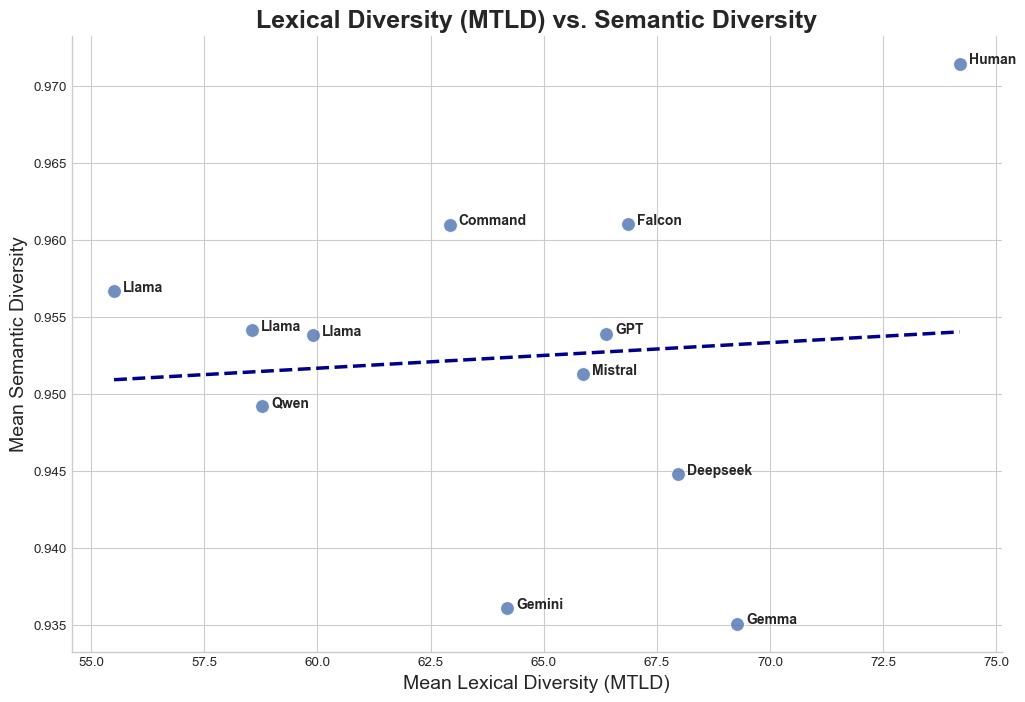



--- Regression Summary: Self-BLEU vs. Semantic Diversity ---
                            OLS Regression Results                            
Dep. Variable:     semantic_diversity   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.092
Method:                 Least Squares   F-statistic:                   0.07391
Date:                Wed, 16 Jul 2025   Prob (F-statistic):              0.791
Time:                        12:40:56   Log-Likelihood:                 38.411
No. Observations:                  12   AIC:                            -72.82
Df Residuals:                      10   BIC:                            -71.85
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

/Users/maxschaffelder/.pyenv/versions/thesis_env/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotest_fun_in(*args, **kwds)


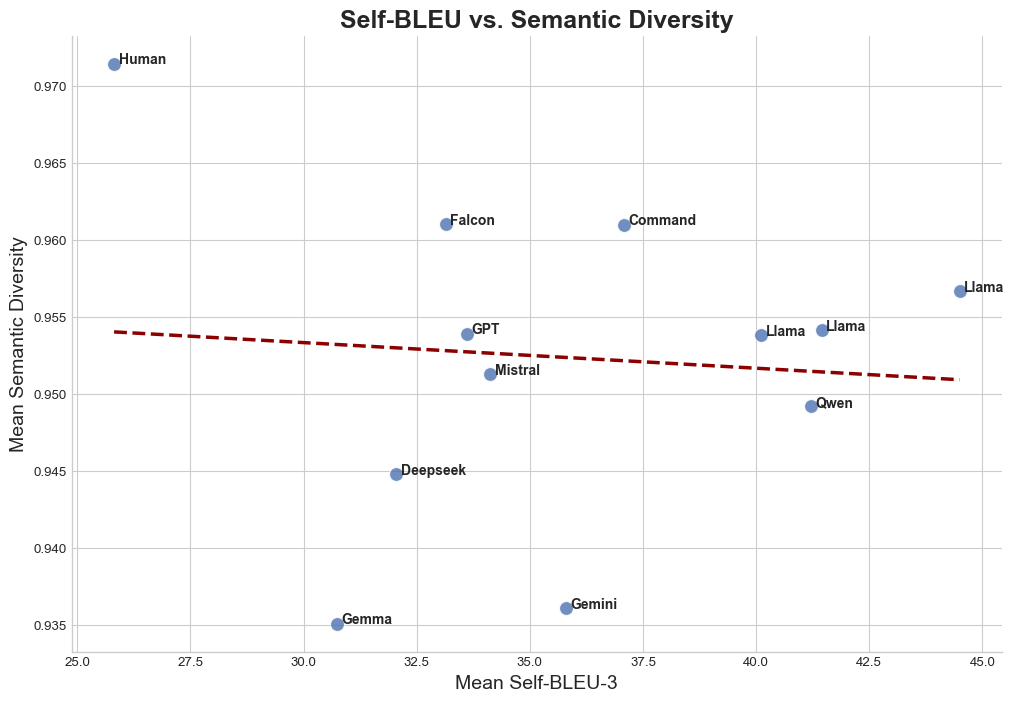

In [60]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

lex_df = pd.read_pickle("/Users/maxschaffelder/Desktop/Thesis/data/data_analysis/self_bleu_combined_3/self_bleu_combined_data.pkl")

# Aggregate by model and size
lex_agg_df = lex_df.groupby(['model', 'size']).agg({
    'lexical_diversity': 'mean',
    'self_bleu_3': 'mean'
}).reset_index()


# 2. Recreate the semantic diversity scores DataFrame.
# This data comes from the first image you provided.
sem_data = {
    'model': ['Falcon', 'Gemma', 'Llama', 'Qwen', 'Command', 'Llama', 'Mistral', 'Qwen', 'Deepseek', 'GPT', 'Gemini', 'Llama', 'Human'],
    'size': ['Small', 'Small', 'Small', 'Small', 'Medium', 'Medium', 'Medium', 'Medium', 'Large', 'Large', 'Large', 'Large', 'Human'],
    'mean_lexical_diversity_old': [83.964625, 86.447662, 75.774552, 83.021232, 82.867762, 77.064378, 80.767552, 80.363553, 82.634676, 83.267374, 82.563046, 79.550648, 89.147000],
    'semantic_diversity': [0.961050, 0.935083, 0.956684, 0.951034, 0.961000, 0.954133, 0.951268, 0.949204, 0.944782, 0.953917, 0.936069, 0.953800, 0.971462]
}
sem_agg_df = pd.DataFrame(sem_data)
# We only need model, size, and semantic_diversity for the merge
sem_agg_df = sem_agg_df[['model', 'size', 'semantic_diversity']]


# 3. Merge the two aggregated DataFrames
final_df = pd.merge(lex_agg_df, sem_agg_df, on=['model', 'size'])

print("--- Merged Data for Final Analysis ---")
display(final_df)


# --- Analysis 1: Lexical Diversity (MTLD) vs. Semantic Diversity ---

# 4. Fit the Linear Regression Model for Lexical Diversity
Y1 = final_df['semantic_diversity']
X1 = sm.add_constant(final_df['lexical_diversity'])
model1 = sm.OLS(Y1, X1)
results1 = model1.fit()

# 5. Display the Statistical Summary
print("\n\n--- Regression Summary: Lexical Diversity vs. Semantic Diversity ---")
print(results1.summary())
print("\n" * 2)

# 6. Visualize the Relationship
print("--- Scatter Plot with Regression Line: Lexical vs. Semantic Diversity ---")
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))

sns.regplot(
    x='lexical_diversity',
    y='semantic_diversity',
    data=final_df,
    ax=ax,
    ci=None,
    scatter_kws={'s': 100, 'alpha': 0.8, 'edgecolor': 'w'},
    line_kws={'color': 'darkblue', 'linestyle': '--', 'linewidth': 2.5}
)

for i, row in final_df.iterrows():
    ax.text(row['lexical_diversity'] + 0.2, row['semantic_diversity'], row['model'], fontsize=10, weight='bold')

ax.set_title('Lexical Diversity (MTLD) vs. Semantic Diversity', fontsize=18, weight='bold')
ax.set_xlabel('Mean Lexical Diversity (MTLD)', fontsize=14)
ax.set_ylabel('Mean Semantic Diversity', fontsize=14)
plt.show()


# --- Analysis 2: Self-BLEU vs. Semantic Diversity ---

# 7. Fit the Linear Regression Model for Self-BLEU
Y2 = final_df['semantic_diversity']
X2 = sm.add_constant(final_df['self_bleu_3'])
model2 = sm.OLS(Y2, X2)
results2 = model2.fit()

# 8. Display the Statistical Summary
print("\n\n--- Regression Summary: Self-BLEU vs. Semantic Diversity ---")
print(results2.summary())
print("\n" * 2)

# 9. Visualize the Relationship
print("--- Scatter Plot with Regression Line: Self-BLEU vs. Semantic Diversity ---")
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))
sns.regplot(
    x='self_bleu_3',
    y='semantic_diversity',
    data=final_df,
    ax=ax,
    ci=None,
    scatter_kws={'s': 100, 'alpha': 0.8, 'edgecolor': 'w'},
    line_kws={'color': 'darkred', 'linestyle': '--', 'linewidth': 2.5}
)

for i, row in final_df.iterrows():
    ax.text(row['self_bleu_3'] + 0.1, row['semantic_diversity'], row['model'], fontsize=10, weight='bold')

ax.set_title('Self-BLEU vs. Semantic Diversity', fontsize=18, weight='bold')
ax.set_xlabel('Mean Self-BLEU-3', fontsize=14)
ax.set_ylabel('Mean Semantic Diversity', fontsize=14)
plt.show()
